In [18]:
import pandas as pd

In [19]:
df = pd.read_csv('WIPO_CRISPR_4_1_25.csv')
df.head(10)

,Application Id,Link,Application Number,Application Date,Country,Title,I P C
0,CN324347467,https://patentscope.wipo.int/search/en/detail....,201911093561.X,11.11.2019,CN,Breeding method for carrying out saturated bas...,C12N 15/29; C12N 15/82; A01H 5/00; A01H 6/46
1,CN417838467,https://patentscope.wipo.int/search/en/detail....,202311185644.8,13.09.2023,CN,Method for improving plant gene editing effici...,C12N 15/82; C12N 15/29; A01H 6/20; A01H 5/00
2,CA382074342,https://patentscope.wipo.int/search/en/detail....,3183409,28.05.2021,CA,LARGE SCALE GENOME MANIPULATION,C12N 15/82
3,CN391941406,https://patentscope.wipo.int/search/en/detail....,202180038896.0,28.05.2021,CN,Large scale genome manipulation,C12N 15/82
4,WO2021243115,https://patentscope.wipo.int/search/en/detail....,PCT/US2021/034704,28.05.2021,WO,LARGE SCALE GENOME MANIPULATION,C12N 15/82
5,EP394881944,https://patentscope.wipo.int/search/en/detail....,21812108,28.05.2021,EP,LARGE SCALE GENOME MANIPULATION,C12N 15/82; C12N 9/22
6,WO2023164550,https://patentscope.wipo.int/search/en/detail....,PCT/US2023/063129,23.02.2023,WO,METHODS AND COMPOSITIONS FOR ADVANCED BREEDING...,A01H 1/00; A01H 1/04; C12N 9/22; A01H 5/10
7,EP445085862,https://patentscope.wipo.int/search/en/detail....,23760919,23.02.2023,EP,METHODS AND COMPOSITIONS FOR ADVANCED BREEDING...,A01H 1/00; A01H 1/04; A01H 5/10; C12N 9/22
8,US400261471,https://patentscope.wipo.int/search/en/detail....,18000067,28.05.2021,US,LARGE SCALE GENOME MANIPULATION,C12N 15/82
9,WO2018099256,https://patentscope.wipo.int/search/en/detail....,PCT/CN2017/110349,10.11.2017,WO,APPLICATION OF CRISPR/NCAS9 MEDIATED SITE-DIRE...,C12N 15/82; A01H 5/00


In [20]:
df.shape

(1498, 7)

In [4]:
df.dtypes

Application Id        object
Link                  object
Application Number    object
Application Date      object
Country               object
Title                 object
I P C                 object
dtype: object

In [5]:
import re

df['year'] = df['Application Date'].str.extract(r'\d\d.\d\d.(\d{4})')
df.head()

,Application Id,Link,Application Number,Application Date,Country,Title,I P C,year
0,CN324347467,https://patentscope.wipo.int/search/en/detail....,201911093561.X,11.11.2019,CN,Breeding method for carrying out saturated bas...,C12N 15/29; C12N 15/82; A01H 5/00; A01H 6/46,2019
1,CN417838467,https://patentscope.wipo.int/search/en/detail....,202311185644.8,13.09.2023,CN,Method for improving plant gene editing effici...,C12N 15/82; C12N 15/29; A01H 6/20; A01H 5/00,2023
2,CA382074342,https://patentscope.wipo.int/search/en/detail....,3183409,28.05.2021,CA,LARGE SCALE GENOME MANIPULATION,C12N 15/82,2021
3,CN391941406,https://patentscope.wipo.int/search/en/detail....,202180038896.0,28.05.2021,CN,Large scale genome manipulation,C12N 15/82,2021
4,WO2021243115,https://patentscope.wipo.int/search/en/detail....,PCT/US2021/034704,28.05.2021,WO,LARGE SCALE GENOME MANIPULATION,C12N 15/82,2021


In [6]:
df['year'].value_counts().reset_index().sort_values(by='year', ascending=False)

,year,count
3,2024,189
0,2023,233
1,2022,221
2,2021,213
4,2020,170
5,2019,159
6,2018,98
7,2017,90
8,2016,57
9,2015,27


In [7]:
df['Country'].value_counts()

Country
CN    1009
US     115
WO     104
EP      56
KR      39
CA      35
AU      28
AR      23
RU      21
IN      14
MX      12
NZ      12
CL       8
JP       6
BR       5
SG       3
GB       3
DK       2
ID       1
IL       1
UY       1
Name: count, dtype: int64

In [8]:
df.groupby('year')['Application Id'].nunique()

year
2013     10
2014     16
2015     27
2016     57
2017     90
2018     98
2019    159
2020    170
2021    213
2022    221
2023    233
2024    189
Name: Application Id, dtype: int64

In [9]:
import numpy as np

countries = pd.pivot_table(df, 
                           values=['Application Id'],
                           index=['year'],
                           columns=['Country'],
                           aggfunc=[len],
                           fill_value=0)

countries.head()

len                              ...                       \
        Application Id                              ...                        
Country             AR AU BR CA CL  CN DK EP GB ID  ... IN JP KR MX NZ RU SG   
year                                                ...                        
2013                 0  0  0  2  0   3  0  3  0  0  ...  0  0  0  0  0  0  0   
2014                 0  1  0  0  0   5  0  1  0  0  ...  0  0  0  0  3  0  0   
2015                 0  1  0  0  0   5  0  4  0  0  ...  1  0  0  3  2  0  0   
2016                 0  3  0  2  0  26  0  5  1  1  ...  0  0  1  0  0  1  0   
2017                 0  3  1  4  0  48  2  6  0  0  ...  2  0  2  0  0  0  0   

                    
                    
Country  US UY  WO  
year                
2013      0  0   2  
2014      3  0   3  
2015      6  0   5  
2016      9  0   8  
2017     10  0  12  

[5 rows x 21 columns]

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>], dtype=object)

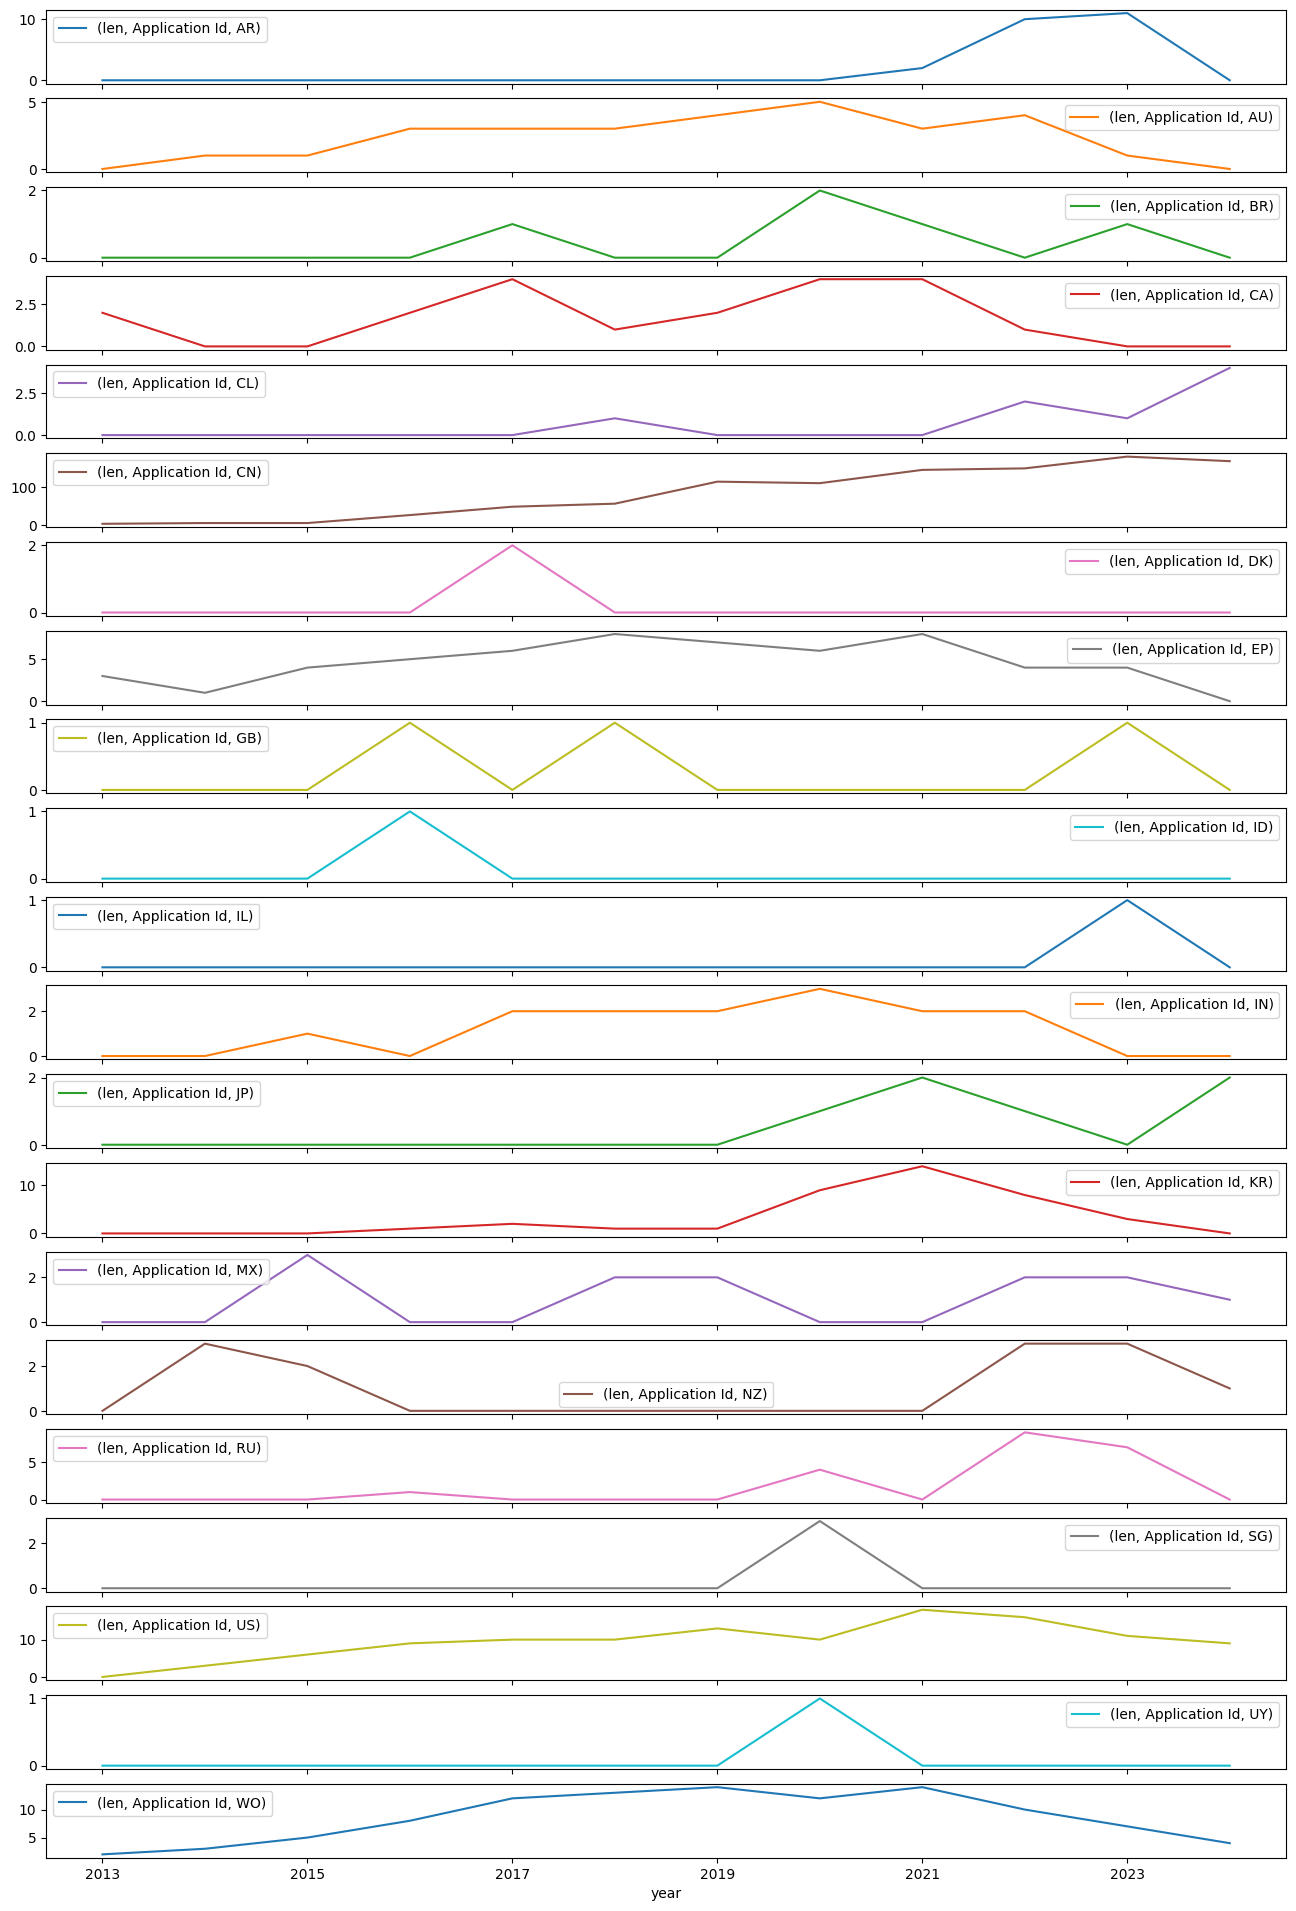

In [10]:
countries.plot.line(subplots=True, figsize=(16,24))

In [11]:
wipo_patents = df.to_dict(orient='records')

In [12]:
wipo_patents[0:5]

[{'Application Id': 'CN324347467',
  'Link': 'https://patentscope.wipo.int/search/en/detail.jsf?docId=CN324347467',
  'Application Number': '201911093561.X',
  'Application Date': '11.11.2019',
  'Country': 'CN',
  'Title': 'Breeding method for carrying out saturated base editing on specific gene of plant',
  'I P C': 'C12N 15/29; C12N 15/82; A01H 5/00; A01H 6/46',
  'year': '2019'},
 {'Application Id': 'CN417838467',
  'Link': 'https://patentscope.wipo.int/search/en/detail.jsf?docId=CN417838467',
  'Application Number': '202311185644.8',
  'Application Date': '13.09.2023',
  'Country': 'CN',
  'Title': 'Method for improving plant gene editing efficiency',
  'I P C': 'C12N 15/82; C12N 15/29; A01H 6/20; A01H 5/00',
  'year': '2023'},
 {'Application Id': 'CA382074342',
  'Link': 'https://patentscope.wipo.int/search/en/detail.jsf?docId=CA382074342',
  'Application Number': '3183409',
  'Application Date': '28.05.2021',
  'Country': 'CA',
  'Title': 'LARGE SCALE GENOME MANIPULATION',
  'I 

In [13]:
import requests
import zipfile
import json

# https://developers.nopecha.com/guides/extension/#loading-the-nopecha-extension-in-a-browser
with open('chromium_automation.zip', 'wb') as f:
    f.write(requests.get('https://github.com/NopeCHALLC/nopecha-extension/releases/latest/download/chromium_automation.zip').content)

with zipfile.ZipFile('chromium_automation.zip', 'r') as zip_ref:
    zip_ref.extractall("nopecha")

In [14]:
import requests

In [15]:
from bs4 import BeautifulSoup

In [16]:
import time

In [17]:
import time
import os
import pandas as pd
import asyncio
import nest_asyncio
from tqdm.asyncio import tqdm  
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup

# Apply nest_asyncio to fix event loop issues in Jupyter
nest_asyncio.apply()

# Function to save data to CSV
def save_to_csv(data, file_name):
    df = pd.DataFrame(data)
    file_exists = os.path.isfile(file_name)
    df.to_csv(file_name, mode='a', header=not file_exists, index=False)

# Define the scraping function
async def scrape_patents(wipo_patents, start_index=466, chunk_size=20):
    biblio_list = []
    patents_to_process = wipo_patents[start_index-1:]  # Start at patent 466

    async with async_playwright() as playwright:
        for i in tqdm(range(0, len(patents_to_process), chunk_size), desc="Processing Patents"):
            chunk = patents_to_process[i:i + chunk_size]  

            for patent in chunk:
                url = patent['Link']
                browser = await playwright.chromium.launch(headless=True)
                page = await browser.new_page()
                await page.goto(url)

                try:
                    await page.wait_for_selector('.ps-biblio-data--biblio-card', timeout=60000)  
                    
                    html = await page.content()
                    soup_doc = BeautifulSoup(html, "html.parser")

                    biblio_dict = {
                        'Application Id': patent['Application Id'],
                        'Application Number': patent['Application Number']
                    }

                    # Scrape main bibliographic data
                    biblio_data = soup_doc.find(class_='ps-biblio-data--biblio-card').find_all('div')
                    biblio_data2 = soup_doc.find(class_='ps-biblio-data--others').find_all('div')

                    for info in biblio_data + biblio_data2:
                        try:
                            label = info.find(class_='ps-field--label ps-biblio-field--label').text.strip()
                            value = info.find(class_='ps-field--value ps-biblio-field--value').text.strip()
                            biblio_dict[label] = value
                        except:
                            continue 

                    # Extract address image if available
                    try:
                        address_image_link = soup_doc.find('ul', class_='biblio-person-list').find('img')['src']
                        biblio_dict['address_image_link'] = address_image_link
                    except:
                        biblio_dict['address_image_link'] = None

                    biblio_list.append(biblio_dict)

                except Exception as e:
                    print(f'{patent["Application Number"]} failed with error: {str(e)}')

                await browser.close()
                time.sleep(5)  # Delay between patents

            save_to_csv(biblio_list, 'patent_data.csv')
            biblio_list = []  # Reset for next chunk
            time.sleep(30)  # Wait between chunks

# ✅ Use `await` directly in Jupyter to properly execute the scraper
await scrape_patents(wipo_patents)

Processing Patents: 100%|████████████████████| 52/52 [5:13:31<00:00, 361.75s/it]
